# 1D Convolutional Autoencoder for Hyperspectral Anomaly Detection

This notebook develops a one-dimensional convolutional autoencoder for unsupervised anomaly detection in AVIRIS hyperspectral imagery.

Unlike a dense autoencoder, the 1D CNN processes neighboring spectral bands together and learns local spectral patterns. Pixels with high reconstruction error are treated as potential anomalies.

In [2]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import torch

from torch import nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)

np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed set to:", RANDOM_STATE)

Random seed set to: 42


In [6]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"

RESULTS_DIR = "../results"

MODELS_DIR = "../models"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

print("Dataset path:", DATA_PATH)

print("Results directory:", RESULTS_DIR)

print("Models directory:", MODELS_DIR)

Dataset path: /Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat
Results directory: ../results
Models directory: ../models


In [8]:
if not os.path.exists(DATA_PATH):

    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Place aviris_1.mat inside the data folder."
    )

print("Dataset found successfully.")

Dataset found successfully.


In [10]:
mat_file = loadmat(
    DATA_PATH
)

print("Variables inside the MAT file:")

for key, value in mat_file.items():

    if not key.startswith("__"):

        print(
            key,
            type(value),
            getattr(
                value,
                "shape",
                None
            )
        )

Variables inside the MAT file:
data <class 'numpy.ndarray'> (100, 100, 189)
map <class 'numpy.ndarray'> (100, 100)


In [12]:
cube = mat_file[
    "data"
].astype(
    np.float32
)

ground_truth = np.squeeze(
    mat_file["map"]
)

ground_truth = (
    ground_truth > 0
).astype(
    np.uint8
)

print(
    "Hyperspectral cube shape:",
    cube.shape
)

print(
    "Ground-truth shape:",
    ground_truth.shape
)

print(
    "Ground-truth values:",
    np.unique(
        ground_truth
    )
)

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Ground-truth values: [0 1]


In [14]:
cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(
    "Number of NaN values:",
    np.isnan(cube).sum()
)

print(
    "Number of infinite values:",
    np.isinf(cube).sum()
)

Number of NaN values: 0
Number of infinite values: 0


In [16]:
height, width, bands = cube.shape

total_pixels = height * width

print("Image height:", height)

print("Image width:", width)

print(
    "Number of spectral bands:",
    bands
)

print(
    "Total number of pixels:",
    total_pixels
)

Image height: 100
Image width: 100
Number of spectral bands: 189
Total number of pixels: 10000


In [18]:
number_of_anomalies = int(
    ground_truth.sum()
)

number_of_background_pixels = (
    total_pixels
    - number_of_anomalies
)

anomaly_percentage = (
    number_of_anomalies
    / total_pixels
) * 100

print(
    "Background pixels:",
    number_of_background_pixels
)

print(
    "Anomaly pixels:",
    number_of_anomalies
)

print(
    f"Anomaly percentage: "
    f"{anomaly_percentage:.4f}%"
)

Background pixels: 9936
Anomaly pixels: 64
Anomaly percentage: 0.6400%


In [20]:
X = cube.reshape(
    -1,
    bands
)

y = ground_truth.reshape(
    -1
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Label vector shape:",
    y.shape
)

Feature matrix shape: (10000, 189)
Label vector shape: (10000,)


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
).astype(
    np.float32
)

print(
    "Scaled feature shape:",
    X_scaled.shape
)

print(
    "Scaled mean:",
    X_scaled.mean()
)

print(
    "Scaled standard deviation:",
    X_scaled.std()
)

Scaled feature shape: (10000, 189)
Scaled mean: 6.9754464e-09
Scaled standard deviation: 0.9999999


In [24]:
X_conv = X_scaled.reshape(
    X_scaled.shape[0],
    1,
    bands
)

print(
    "Conv1D input shape:",
    X_conv.shape
)

Conv1D input shape: (10000, 1, 189)


In [26]:
X_tensor = torch.tensor(
    X_conv,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor
)

print(
    "Number of samples:",
    len(dataset)
)

print(
    "Single sample shape:",
    dataset[0][0].shape
)

Number of samples: 10000
Single sample shape: torch.Size([1, 189])


In [28]:
training_size = int(
    0.85
    * len(dataset)
)

validation_size = (
    len(dataset)
    - training_size
)

training_dataset, validation_dataset = random_split(
    dataset,
    [
        training_size,
        validation_size
    ],
    generator=torch.Generator().manual_seed(
        RANDOM_STATE
    )
)

print(
    "Training samples:",
    len(training_dataset)
)

print(
    "Validation samples:",
    len(validation_dataset)
)

Training samples: 8500
Validation samples: 1500


In [30]:
BATCH_SIZE = 256

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training batches:",
    len(training_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

Training batches: 34
Validation batches: 6


In [50]:
class Conv1DAutoencoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=7,
                padding=3
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(
                kernel_size=2
            ),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Upsample(
                scale_factor=2,
                mode="linear",
                align_corners=False
            ),

            nn.Conv1d(
                in_channels=64,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Upsample(
                scale_factor=2,
                mode="linear",
                align_corners=False
            ),

            nn.Conv1d(
                in_channels=32,
                out_channels=16,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.Conv1d(
                in_channels=16,
                out_channels=1,
                kernel_size=7,
                padding=3
            )
        )

    def forward(self, x):

        original_length = x.shape[-1]

        latent_features = self.encoder(
            x
        )

        reconstructed_spectrum = self.decoder(
            latent_features
        )

        reconstructed_spectrum = nn.functional.interpolate(
            reconstructed_spectrum,
            size=original_length,
            mode="linear",
            align_corners=False
        )

        return reconstructed_spectrum

In [52]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device being used:", device)

Device being used: cpu


In [54]:
model = Conv1DAutoencoder()

model = model.to(
    device
)

print(model)

Conv1DAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='linear')
    (1): Conv1d(64, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='linear')
    (4): Conv1d(32, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): ReLU()
    (6): Conv1d(16, 1, kernel_size=(7,), stride=(1,), padding=(3,))
  )
)


In [56]:
example_batch = next(
    iter(training_loader)
)[0]

example_batch = example_batch.to(
    device
)

with torch.no_grad():

    example_output = model(
        example_batch
    )

print(
    "Input shape:",
    example_batch.shape
)

print(
    "Output shape:",
    example_output.shape
)

Input shape: torch.Size([256, 1, 189])
Output shape: torch.Size([256, 1, 189])


In [58]:
number_of_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)

print(
    "Number of trainable parameters:",
    number_of_parameters
)

Number of trainable parameters: 17793


In [60]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.00001
)

print(
    "Loss function:",
    loss_function
)

print(
    "Optimizer:",
    optimizer
)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [62]:
def train_conv1d_autoencoder(
    model,
    training_loader,
    validation_loader,
    loss_function,
    optimizer,
    device,
    maximum_epochs=100,
    patience=12
):

    training_loss_history = []

    validation_loss_history = []

    best_validation_loss = float(
        "inf"
    )

    best_model_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        maximum_epochs + 1
    ):

        model.train()

        total_training_loss = 0.0

        for batch in training_loader:

            spectra = batch[0].to(
                device
            )

            optimizer.zero_grad()

            reconstructed_spectra = model(
                spectra
            )

            loss = loss_function(
                reconstructed_spectra,
                spectra
            )

            loss.backward()

            optimizer.step()

            total_training_loss += (
                loss.item()
                * spectra.size(0)
            )

        average_training_loss = (
            total_training_loss
            / len(
                training_loader.dataset
            )
        )

        model.eval()

        total_validation_loss = 0.0

        with torch.no_grad():

            for batch in validation_loader:

                spectra = batch[0].to(
                    device
                )

                reconstructed_spectra = model(
                    spectra
                )

                validation_loss = loss_function(
                    reconstructed_spectra,
                    spectra
                )

                total_validation_loss += (
                    validation_loss.item()
                    * spectra.size(0)
                )

        average_validation_loss = (
            total_validation_loss
            / len(
                validation_loader.dataset
            )
        )

        training_loss_history.append(
            average_training_loss
        )

        validation_loss_history.append(
            average_validation_loss
        )

        if (
            average_validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                average_validation_loss
            )

            best_model_state = {

                key: value.cpu().clone()

                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"Training Loss: "
                f"{average_training_loss:.6f} | "
                f"Validation Loss: "
                f"{average_validation_loss:.6f}"
            )

        if (
            epochs_without_improvement
            >= patience
        ):

            print(
                "Early stopping activated."
            )

            break

    model.load_state_dict(
        best_model_state
    )

    return (
        training_loss_history,
        validation_loss_history
    )

In [64]:
start_time = time.time()

training_losses, validation_losses = train_conv1d_autoencoder(
    model=model,
    training_loader=training_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    maximum_epochs=100,
    patience=12
)

training_time = (
    time.time()
    - start_time
)

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

Epoch 001 | Training Loss: 0.355556 | Validation Loss: 0.024102
Epoch 010 | Training Loss: 0.001568 | Validation Loss: 0.001413
Epoch 020 | Training Loss: 0.001173 | Validation Loss: 0.001140
Epoch 030 | Training Loss: 0.001083 | Validation Loss: 0.001080
Epoch 040 | Training Loss: 0.001168 | Validation Loss: 0.001001
Epoch 050 | Training Loss: 0.000913 | Validation Loss: 0.000909
Epoch 060 | Training Loss: 0.000887 | Validation Loss: 0.000884
Epoch 070 | Training Loss: 0.000853 | Validation Loss: 0.000848
Epoch 080 | Training Loss: 0.000851 | Validation Loss: 0.000855
Epoch 090 | Training Loss: 0.000821 | Validation Loss: 0.000802
Epoch 100 | Training Loss: 0.000835 | Validation Loss: 0.000773
Training completed in 160.93 seconds.


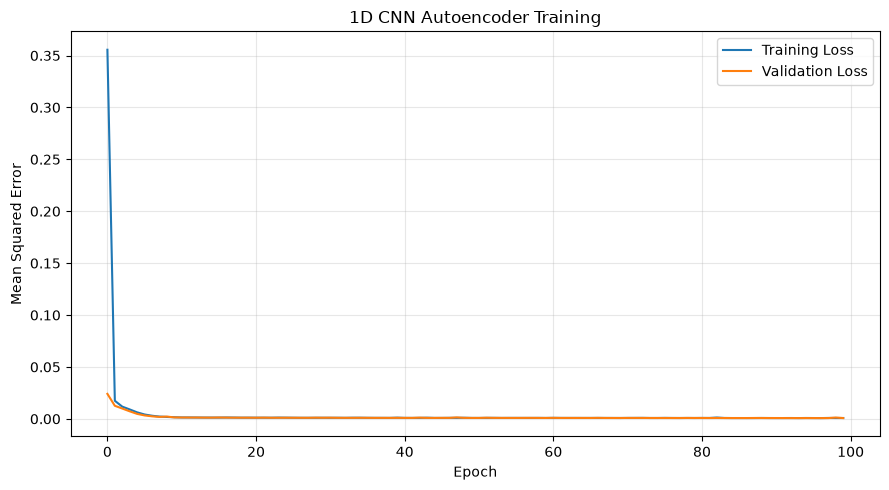

In [66]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    training_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "1D CNN Autoencoder Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [68]:
model.eval()

all_spectra_tensor = torch.tensor(
    X_conv,
    dtype=torch.float32
).to(
    device
)

with torch.no_grad():

    reconstructed_spectra = model(
        all_spectra_tensor
    )

reconstructed_spectra = (
    reconstructed_spectra
    .cpu()
    .numpy()
)

print(
    "Reconstructed spectra shape:",
    reconstructed_spectra.shape
)

Reconstructed spectra shape: (10000, 1, 189)


In [70]:
reconstruction_errors = np.mean(
    (
        X_conv
        - reconstructed_spectra
    ) ** 2,
    axis=(
        1,
        2
    )
)

print(
    "Minimum reconstruction error:",
    reconstruction_errors.min()
)

print(
    "Maximum reconstruction error:",
    reconstruction_errors.max()
)

print(
    "Mean reconstruction error:",
    reconstruction_errors.mean()
)

Minimum reconstruction error: 0.00017255815
Maximum reconstruction error: 0.019104803
Mean reconstruction error: 0.00076193473


In [72]:
conv1d_anomaly_map = reconstruction_errors.reshape(
    height,
    width
)

print(
    "Anomaly map shape:",
    conv1d_anomaly_map.shape
)

Anomaly map shape: (100, 100)


In [74]:
normalized_anomaly_map = (
    conv1d_anomaly_map
    - conv1d_anomaly_map.min()
) / (
    conv1d_anomaly_map.max()
    - conv1d_anomaly_map.min()
    + 1e-8
)

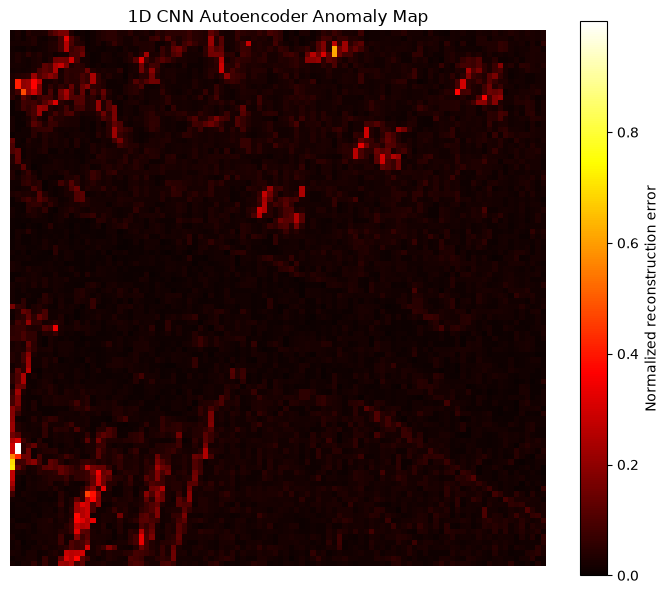

In [76]:
plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    normalized_anomaly_map,
    cmap="hot"
)

plt.title(
    "1D CNN Autoencoder Anomaly Map"
)

plt.colorbar(
    label="Normalized reconstruction error"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()

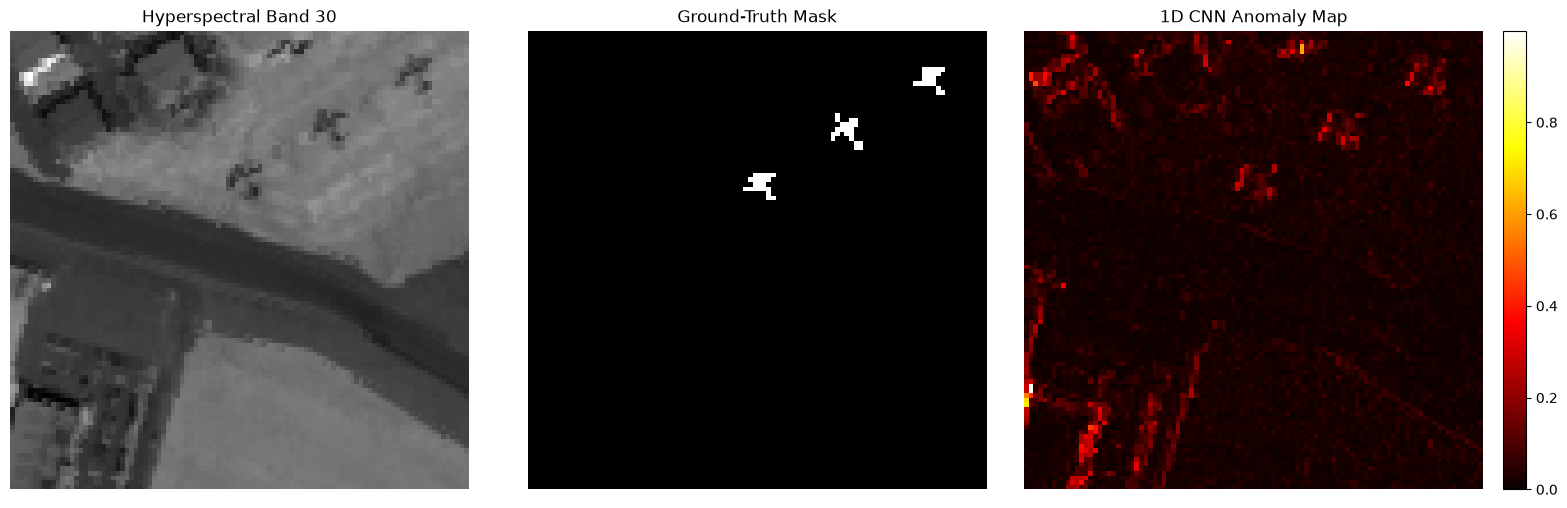

In [78]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

axes[0].imshow(
    cube[:, :, 30],
    cmap="gray"
)

axes[0].set_title(
    "Hyperspectral Band 30"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "Ground-Truth Mask"
)

axes[1].axis(
    "off"
)

image = axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "1D CNN Anomaly Map"
)

axes[2].axis(
    "off"
)

figure.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()

In [80]:
roc_auc = roc_auc_score(
    y,
    reconstruction_errors
)

pr_auc = average_precision_score(
    y,
    reconstruction_errors
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

ROC-AUC: 0.8944
PR-AUC: 0.0350


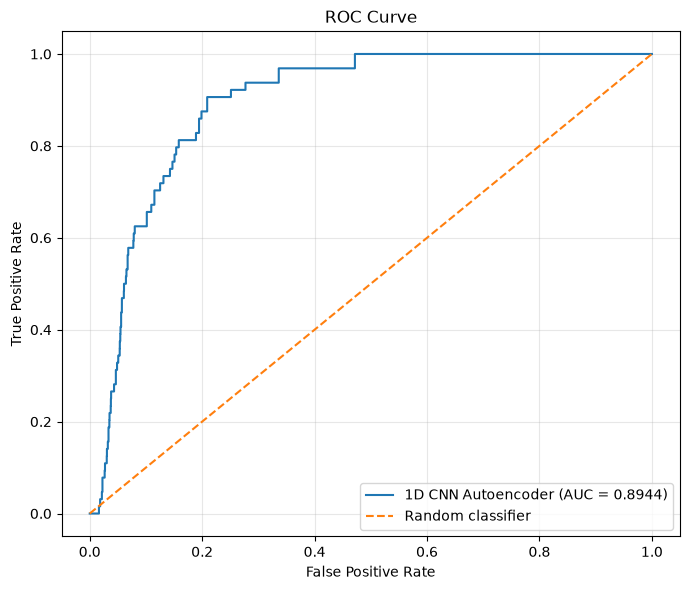

In [82]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        f"1D CNN Autoencoder "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

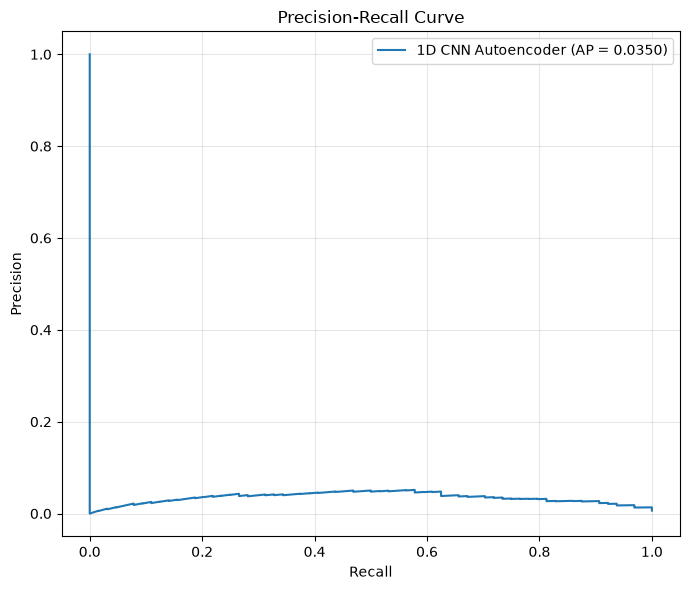

In [84]:
precision_values, recall_values, _ = precision_recall_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"1D CNN Autoencoder "
        f"(AP = {pr_auc:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [86]:
THRESHOLD_PERCENTILE = 99

threshold = np.percentile(
    reconstruction_errors,
    THRESHOLD_PERCENTILE
)

predicted_labels = (
    reconstruction_errors
    >= threshold
).astype(
    np.uint8
)

predicted_mask = predicted_labels.reshape(
    height,
    width
)

print(
    "Threshold:",
    threshold
)

print(
    "Predicted anomaly pixels:",
    predicted_labels.sum()
)

Threshold: 0.004678516183048487
Predicted anomaly pixels: 101


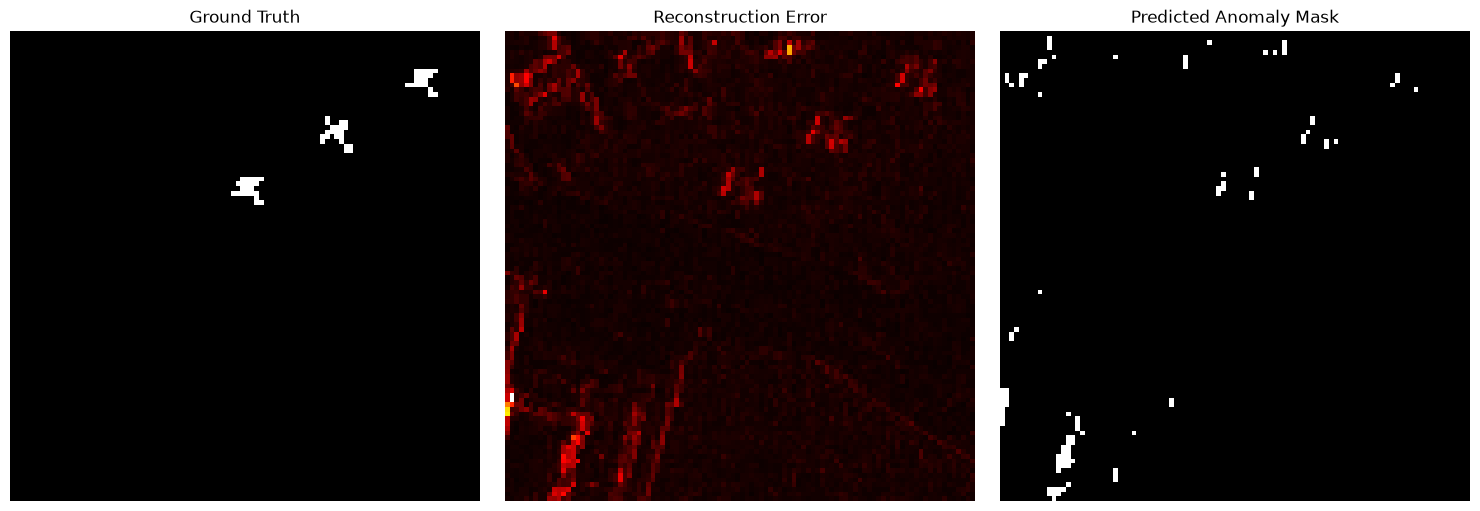

In [88]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    ground_truth,
    cmap="gray"
)

axes[0].set_title(
    "Ground Truth"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[1].set_title(
    "Reconstruction Error"
)

axes[1].axis(
    "off"
)

axes[2].imshow(
    predicted_mask,
    cmap="gray"
)

axes[2].set_title(
    "Predicted Anomaly Mask"
)

axes[2].axis(
    "off"
)

plt.tight_layout()

plt.show()

In [90]:
print(
    classification_report(
        y,
        predicted_labels,
        target_names=[
            "Background",
            "Anomaly"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9935    0.9898    0.9917      9936
     Anomaly     0.0000    0.0000    0.0000        64

    accuracy                         0.9835     10000
   macro avg     0.4968    0.4949    0.4958     10000
weighted avg     0.9872    0.9835    0.9853     10000



In [92]:
confusion_matrix_values = confusion_matrix(
    y,
    predicted_labels
)

confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[
        "Actual Background",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Background",
        "Predicted Anomaly"
    ]
)

confusion_matrix_table

,Predicted Background,Predicted Anomaly
Actual Background,9835,101
Actual Anomaly,64,0


In [94]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix_values.ravel()
)

precision_score_value = (
    true_positive
    / (
        true_positive
        + false_positive
        + 1e-8
    )
)

recall_score_value = (
    true_positive
    / (
        true_positive
        + false_negative
        + 1e-8
    )
)

f1_score_value = (
    2
    * precision_score_value
    * recall_score_value
    / (
        precision_score_value
        + recall_score_value
        + 1e-8
    )
)

specificity = (
    true_negative
    / (
        true_negative
        + false_positive
        + 1e-8
    )
)

false_positive_rate_value = (
    false_positive
    / (
        false_positive
        + true_negative
        + 1e-8
    )
)

print(
    "True positives:",
    true_positive
)

print(
    "False positives:",
    false_positive
)

print(
    "False negatives:",
    false_negative
)

print(
    "True negatives:",
    true_negative
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    f"False-positive rate: "
    f"{false_positive_rate_value:.6f}"
)

True positives: 0
False positives: 101
False negatives: 64
True negatives: 9835
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Specificity: 0.9898
False-positive rate: 0.010165


In [96]:
normal_errors = reconstruction_errors[
    y == 0
]

anomaly_errors = reconstruction_errors[
    y == 1
]

print(
    "Mean background reconstruction error:",
    normal_errors.mean()
)

print(
    "Mean anomaly reconstruction error:",
    anomaly_errors.mean()
)

print(
    "Median background reconstruction error:",
    np.median(normal_errors)
)

print(
    "Median anomaly reconstruction error:",
    np.median(anomaly_errors)
)

Mean background reconstruction error: 0.00075630634
Mean anomaly reconstruction error: 0.0016357463
Median background reconstruction error: 0.00055680284
Median anomaly reconstruction error: 0.0015754277


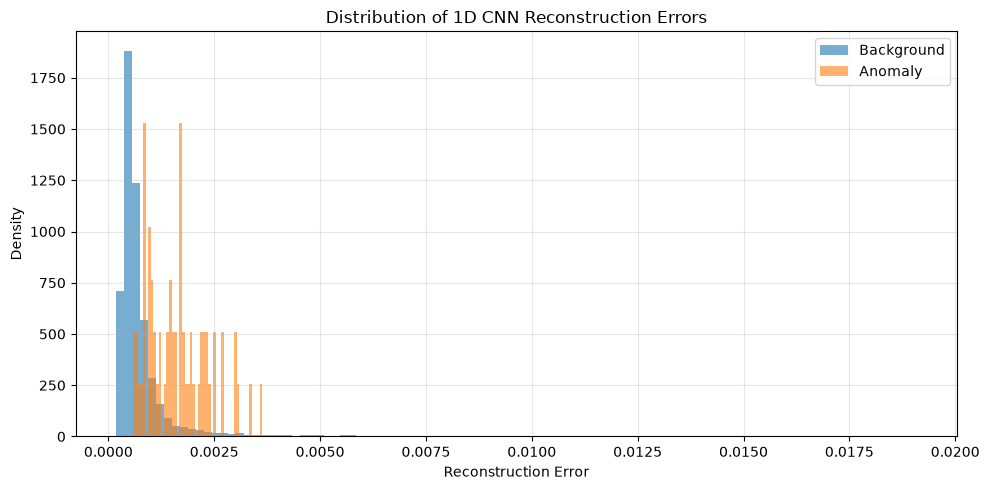

In [98]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    normal_errors,
    bins=100,
    alpha=0.6,
    label="Background",
    density=True
)

plt.hist(
    anomaly_errors,
    bins=50,
    alpha=0.6,
    label="Anomaly",
    density=True
)

plt.xlabel(
    "Reconstruction Error"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Distribution of 1D CNN Reconstruction Errors"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [100]:
normal_pixel_index = np.where(
    y == 0
)[0][0]

anomaly_pixel_index = np.where(
    y == 1
)[0][0]

print(
    "Normal pixel index:",
    normal_pixel_index
)

print(
    "Anomaly pixel index:",
    anomaly_pixel_index
)

Normal pixel index: 0
Anomaly pixel index: 886


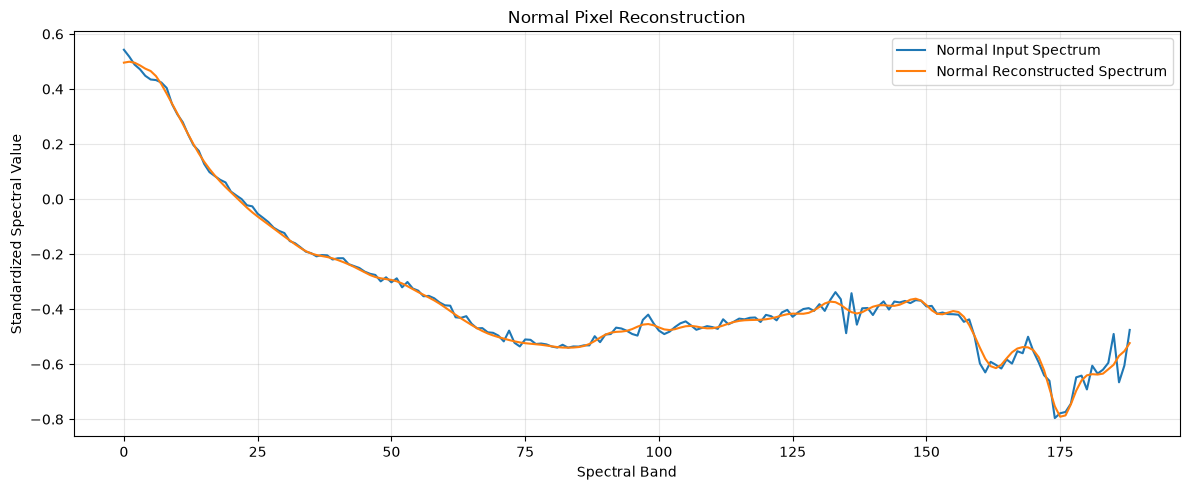

In [102]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_conv[
        normal_pixel_index,
        0,
        :
    ],
    label="Normal Input Spectrum"
)

plt.plot(
    reconstructed_spectra[
        normal_pixel_index,
        0,
        :
    ],
    label="Normal Reconstructed Spectrum"
)

plt.xlabel(
    "Spectral Band"
)

plt.ylabel(
    "Standardized Spectral Value"
)

plt.title(
    "Normal Pixel Reconstruction"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

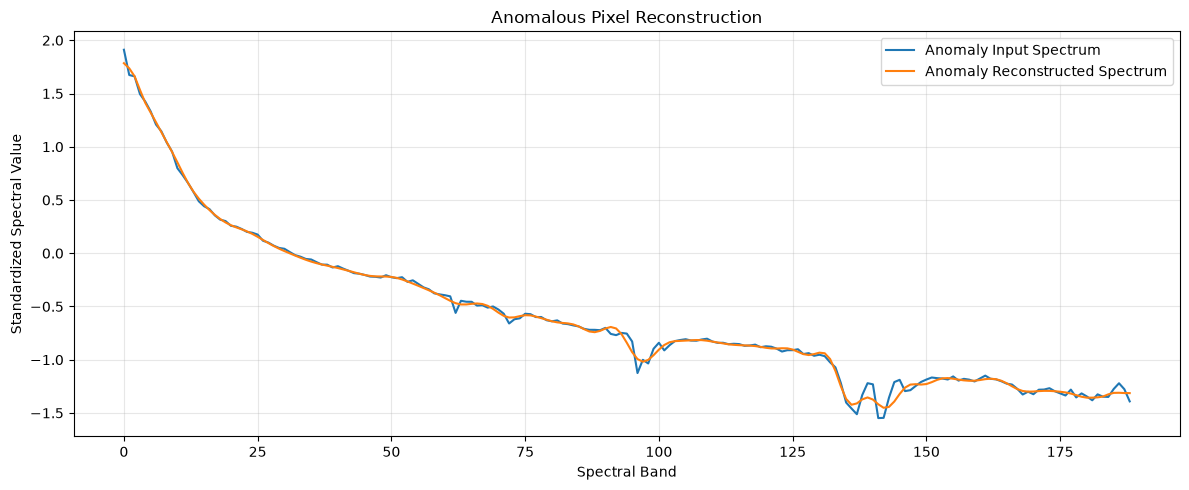

In [104]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_conv[
        anomaly_pixel_index,
        0,
        :
    ],
    label="Anomaly Input Spectrum"
)

plt.plot(
    reconstructed_spectra[
        anomaly_pixel_index,
        0,
        :
    ],
    label="Anomaly Reconstructed Spectrum"
)

plt.xlabel(
    "Spectral Band"
)

plt.ylabel(
    "Standardized Spectral Value"
)

plt.title(
    "Anomalous Pixel Reconstruction"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [106]:
model.eval()

with torch.no_grad():

    latent_features = model.encoder(
        all_spectra_tensor
    )

latent_features = (
    latent_features
    .cpu()
    .numpy()
)

print(
    "Latent feature shape:",
    latent_features.shape
)

Latent feature shape: (10000, 64, 47)


In [108]:
compact_embeddings = np.mean(
    latent_features,
    axis=2
)

print(
    "Compact embedding shape:",
    compact_embeddings.shape
)

Compact embedding shape: (10000, 64)


In [110]:
from sklearn.decomposition import PCA

embedding_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

two_dimensional_embeddings = embedding_pca.fit_transform(
    compact_embeddings
)

print(
    "Explained variance:",
    embedding_pca.explained_variance_ratio_
)

Explained variance: [0.7709029  0.22470443]


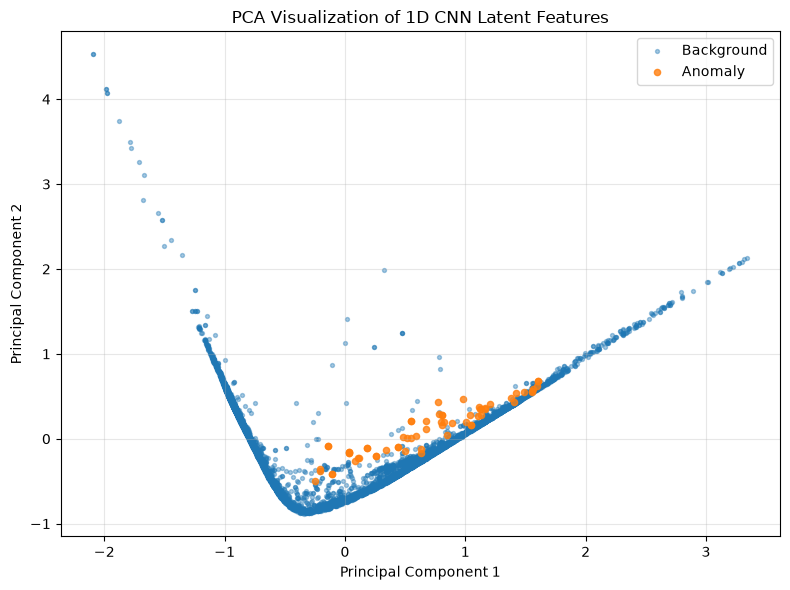

In [112]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    two_dimensional_embeddings[
        y == 0,
        0
    ],
    two_dimensional_embeddings[
        y == 0,
        1
    ],
    s=8,
    alpha=0.4,
    label="Background"
)

plt.scatter(
    two_dimensional_embeddings[
        y == 1,
        0
    ],
    two_dimensional_embeddings[
        y == 1,
        1
    ],
    s=20,
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Visualization of 1D CNN Latent Features"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [114]:
MODEL_PATH = os.path.join(
    MODELS_DIR,
    "conv1d_autoencoder.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "number_of_bands": bands,
        "random_state": RANDOM_STATE,
        "training_losses": training_losses,
        "validation_losses": validation_losses
    },
    MODEL_PATH
)

print(
    "Model saved to:",
    MODEL_PATH
)

Model saved to: ../models/conv1d_autoencoder.pt


In [116]:
SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_scores.npy"
)

np.save(
    SCORE_PATH,
    conv1d_anomaly_map
)

print(
    "Anomaly scores saved to:",
    SCORE_PATH
)

Anomaly scores saved to: ../results/conv1d_autoencoder_scores.npy


In [118]:
EMBEDDING_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_compact_embeddings.npy"
)

np.save(
    EMBEDDING_PATH,
    compact_embeddings
)

print(
    "Compact embeddings saved to:",
    EMBEDDING_PATH
)

Compact embeddings saved to: ../results/conv1d_compact_embeddings.npy


In [120]:
import joblib

SCALER_PATH = os.path.join(
    MODELS_DIR,
    "conv1d_standard_scaler.joblib"
)

joblib.dump(
    scaler,
    SCALER_PATH
)

print(
    "Scaler saved to:",
    SCALER_PATH
)

Scaler saved to: ../models/conv1d_standard_scaler.joblib


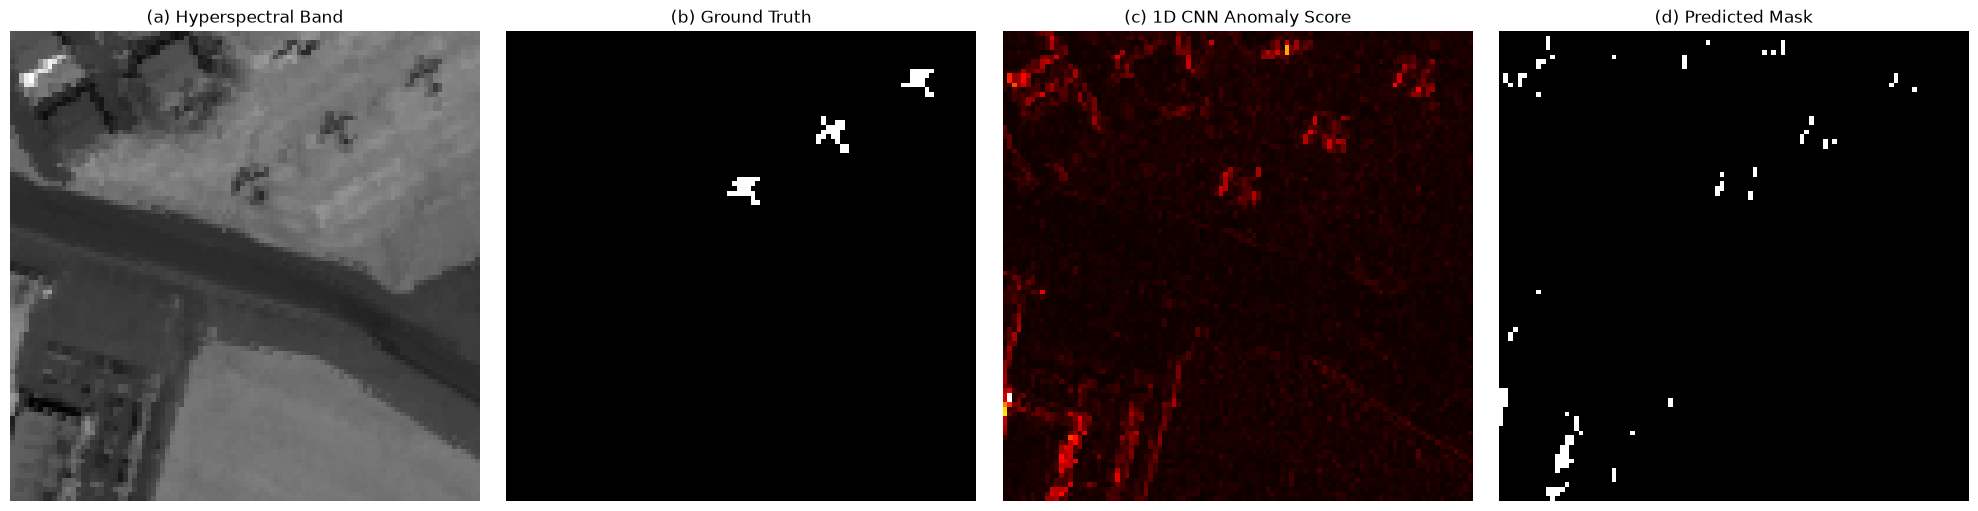

Figure saved to: ../results/conv1d_autoencoder_results.png


In [122]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    cube[:, :, 30],
    cmap="gray"
)

axes[0].set_title(
    "(a) Hyperspectral Band"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "(b) Ground Truth"
)

axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "(c) 1D CNN Anomaly Score"
)

axes[3].imshow(
    predicted_mask,
    cmap="gray"
)

axes[3].set_title(
    "(d) Predicted Mask"
)

for axis in axes:

    axis.axis(
        "off"
    )

plt.tight_layout()

FIGURE_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_results.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:",
    FIGURE_PATH
)

In [124]:
results_table = pd.DataFrame(
    {
        "Dataset": [
            "AVIRIS-1 San Diego"
        ],

        "Model": [
            "1D CNN Autoencoder"
        ],

        "ROC_AUC": [
            roc_auc
        ],

        "PR_AUC": [
            pr_auc
        ],

        "Threshold_Percentile": [
            THRESHOLD_PERCENTILE
        ],

        "Precision": [
            precision_score_value
        ],

        "Recall": [
            recall_score_value
        ],

        "F1": [
            f1_score_value
        ],

        "Specificity": [
            specificity
        ],

        "False_Positive_Rate": [
            false_positive_rate_value
        ],

        "Training_Time_Seconds": [
            training_time
        ],

        "Trainable_Parameters": [
            number_of_parameters
        ]
    }
)

results_table

,Dataset,Model,ROC_AUC,PR_AUC,Threshold_Percentile,Precision,Recall,F1,Specificity,False_Positive_Rate,Training_Time_Seconds,Trainable_Parameters
0,AVIRIS-1 San Diego,1D CNN Autoencoder,0.894406,0.035033,99,0.0,0.0,0.0,0.989835,0.010165,160.925139,17793


In [126]:
METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_metrics.csv"
)

results_table.to_csv(
    METRICS_PATH,
    index=False
)

print(
    "Metrics saved to:",
    METRICS_PATH
)

Metrics saved to: ../results/conv1d_autoencoder_metrics.csv


In [128]:
DENSE_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_metrics.csv"
)

if os.path.exists(
    DENSE_METRICS_PATH
):

    dense_results = pd.read_csv(
        DENSE_METRICS_PATH
    )

    model_comparison = pd.concat(
        [
            dense_results,
            results_table
        ],
        ignore_index=True
    )

    display_columns = [
        "Model",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1",
        "Training_Time_Seconds",
        "Trainable_Parameters"
    ]

    print(
        "Dense autoencoder and 1D CNN comparison:"
    )

    display(
        model_comparison[
            display_columns
        ].round(4)
    )

else:

    print(
        "Dense autoencoder metrics were not found."
    )

Dense autoencoder and 1D CNN comparison:


,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Training_Time_Seconds,Trainable_Parameters
0,Spectral Dense Autoencoder,0.9106,0.0346,0.0,0.0,0.0,5.3244,69725
1,1D CNN Autoencoder,0.8944,0.0350,0.0,0.0,0.0,160.9251,17793


In [130]:
COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "autoencoder_model_comparison.csv"
)

if os.path.exists(
    DENSE_METRICS_PATH
):

    model_comparison.to_csv(
        COMPARISON_PATH,
        index=False
    )

    print(
        "Combined comparison saved to:",
        COMPARISON_PATH
    )

else:

    print(
        "Combined comparison was not saved because "
        "the dense autoencoder metrics file was not found."
    )

Combined comparison saved to: ../results/autoencoder_model_comparison.csv


In [132]:
print("=" * 70)

print(
    "1D CONVOLUTIONAL AUTOENCODER "
    "EXPERIMENT SUMMARY"
)

print("=" * 70)

print(
    "Dataset: AVIRIS-1 San Diego"
)

print(
    "Cube shape:",
    cube.shape
)

print(
    "Input format:",
    X_conv.shape
)

print(
    "Model: 1D CNN Autoencoder"
)

print(
    "Trainable parameters:",
    number_of_parameters
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc:.4f}"
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Saved anomaly map:",
    SCORE_PATH
)

print(
    "Saved embeddings:",
    EMBEDDING_PATH
)

print("=" * 70)

1D CONVOLUTIONAL AUTOENCODER EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Cube shape: (100, 100, 189)
Input format: (10000, 1, 189)
Model: 1D CNN Autoencoder
Trainable parameters: 17793
Training time: 160.93 seconds
ROC-AUC: 0.8944
PR-AUC: 0.0350
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Specificity: 0.9898
Saved model: ../models/conv1d_autoencoder.pt
Saved anomaly map: ../results/conv1d_autoencoder_scores.npy
Saved embeddings: ../results/conv1d_compact_embeddings.npy
